# Iris Dataset Analysis and KNN Classification

This notebook performs EDA and trains a K-Nearest Neighbors classifier on the Iris dataset.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

%matplotlib inline
sns.set_style('whitegrid')

In [3]:
# Load data
data = pd.read_csv('Iris.csv')

# Drop Id column
data = data.drop('Id', axis=1)

# Encode species
le = LabelEncoder()
data['Species'] = le.fit_transform(data['Species'])

print(data.head(10))
print(data.dtypes)
print('Missing values:\n', data.isnull().sum())
print(data.describe())

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  Species
0            5.1           3.5            1.4           0.2        0
1            4.9           3.0            1.4           0.2        0
2            4.7           3.2            1.3           0.2        0
3            4.6           3.1            1.5           0.2        0
4            5.0           3.6            1.4           0.2        0
5            5.4           3.9            1.7           0.4        0
6            4.6           3.4            1.4           0.3        0
7            5.0           3.4            1.5           0.2        0
8            4.4           2.9            1.4           0.2        0
9            4.9           3.1            1.5           0.1        0
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species            int64
dtype: object
Missing values:
 SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species  

Numerical features: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']


<Figure size 1000x800 with 0 Axes>

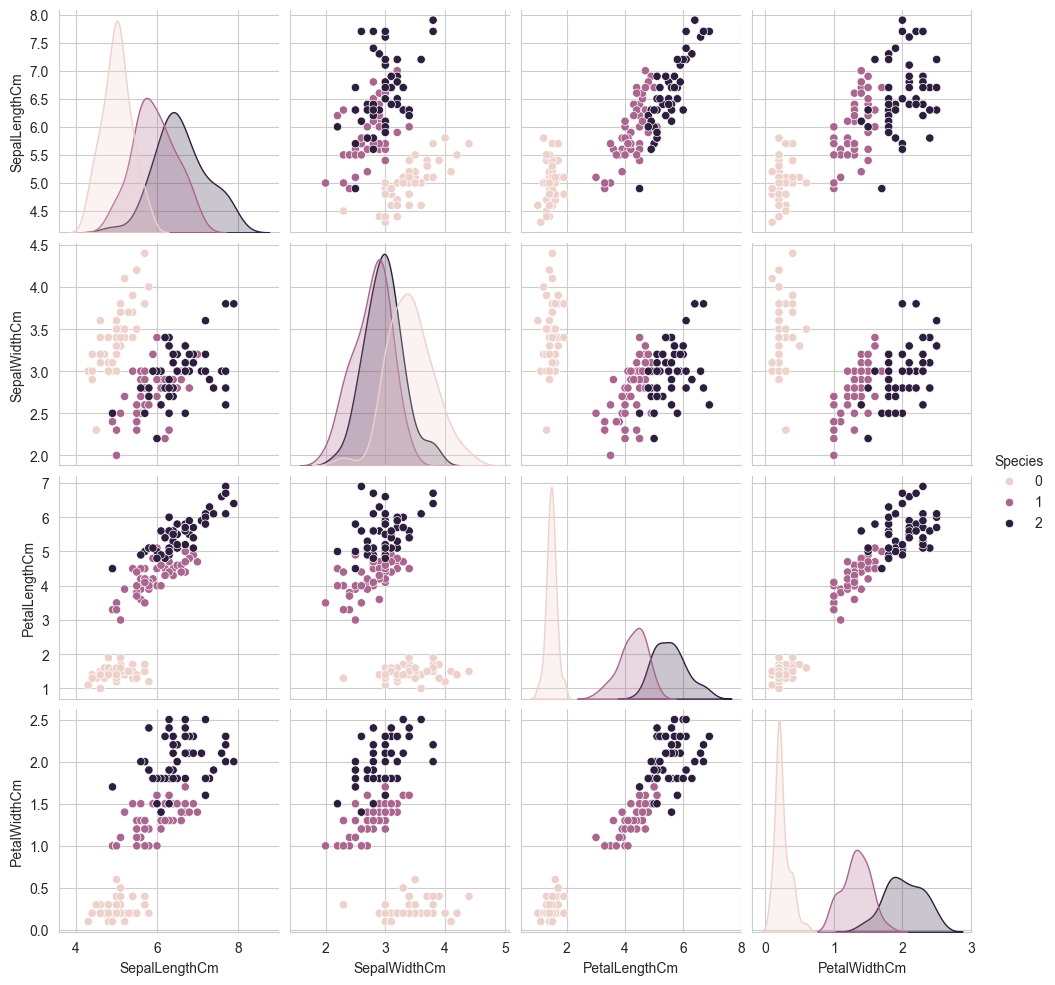

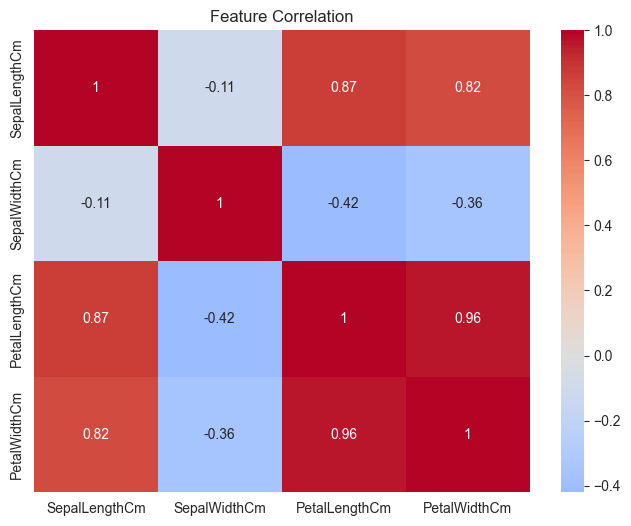

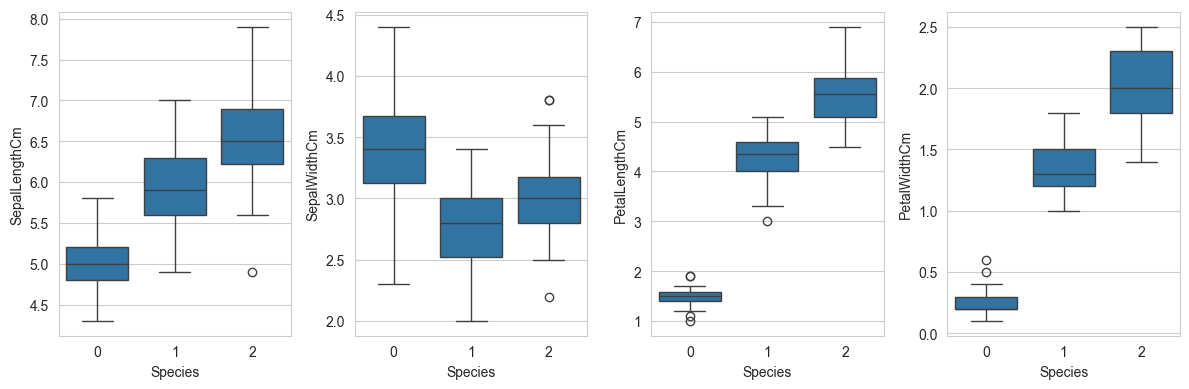

In [4]:
# Numerical features
num_features = data.select_dtypes(include=[np.number]).columns.tolist()
print('Numerical features:', num_features)

# Pairplot
plt.figure(figsize=(10, 8))
sns.pairplot(data, vars=num_features[:-1], hue='Species')
plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(data[num_features[:-1]].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation')
plt.show()

# Boxplots
plt.figure(figsize=(12, 4))
for i, col in enumerate(num_features[:-1]):
    plt.subplot(1, 4, i+1)
    sns.boxplot(data=data, x='Species', y=col)
plt.tight_layout()
plt.show()

In [5]:
# Prepare data
X = data[num_features[:-1]]
y = data['Species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (120, 4)
Test shape: (30, 4)


In [6]:
# KNN k-tuning
k_values = [3, 5, 7, 9, 11]
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f'K={k}: {acc:.4f}')

best_k = k_values[np.argmax(accuracies)]
print(f'\nBest K: {best_k}')

K=3: 1.0000
K=5: 1.0000
K=7: 0.9667
K=9: 1.0000
K=11: 0.9667

Best K: 3


Test Accuracy: 1.0


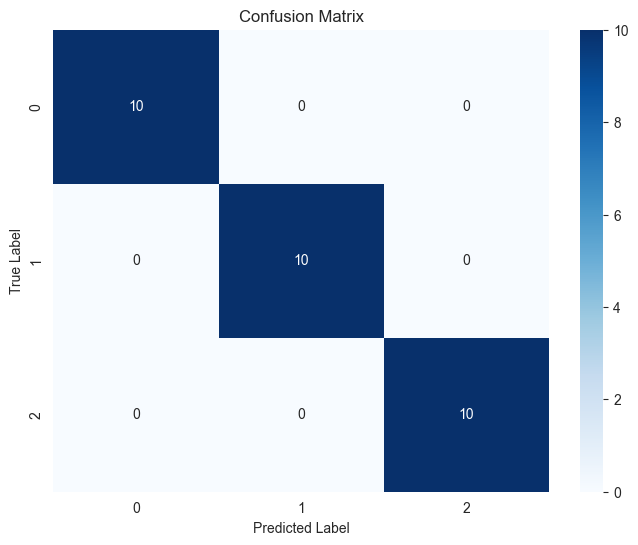

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [7]:
# Best model
best_model = KNeighborsClassifier(n_neighbors=best_k)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print('Test Accuracy:', accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print(classification_report(y_test, y_pred, target_names=le.classes_))

In [8]:
# Cross-validation
cv_scores = cross_val_score(best_model, X, y, cv=5)
print('Cross-val scores:', cv_scores)
print('Mean CV accuracy:', cv_scores.mean().round(4), '+/-', cv_scores.std()*2)

Cross-val scores: [0.96666667 0.96666667 0.93333333 0.96666667 1.        ]
Mean CV accuracy: 0.9667 +/- 0.04216370213557838
